PROGETTO 7: CLASSIFICAZIONE IBRIDA DI DOCUMENTI

Sfida sensoriale
Un essere umano se gli viene passato un foglio di carte capisce se è una fattura, una lettera d'amore, semplicemente guardo il layout.

Quindi diamo alle macchina la vista per il layout e l'intelletto per il contenuto.

- Analisi della pipeline ibrida: come far dialogare pixel e parole
- Architetture degli occhi ovvero CNN specializzate a riconoscere la firma strutturale di un documento (senza leggere il testo)
- Classificazione multi classe, distingue fatture, contratti e carte d'identità in scenari reali.

Perchè una soluzione ibrida è meglio di una pura?

L'approccio Multimedial

Se volessimo spiegare ad un pc la differenza tra un giornale ed un libro, punteremmo sulla forma delle colonne e delle immagini
L'AI ibrida agisce come un impiegato esperto che smista la posta.
Se l' OCR è sporco o il documento rovinato, il sistema non va nel panico, perchè ha ancora il senso della vista che gli dice "guarda, ha la forma di una fattura".
Un impiegato espoerto riconosce il modulo a colpo d'occio (vista), ma legge anche le parole chieve per confermane la natura (OCR)
Un approccio solo testuale fallisce se l'OCR è sporco, un approccio solo visivo fallisce tra documenti con layout simili.
La pipeline ibrida combina un ramo convoluzionale (RNN) per catturare pattern spaziali, loghi e tabelle, con un ramo NLP (embedding o Transformer) per interpretare il lessi specifico, creando un vettore di caratteristiche fuso che rappresenta l'essendo del documento.

Ma come si fondono, tecnicamente, queste due anime così diverse?

Fondamenti della Pipeline Ibrida
Integrazione di rami neurali etorogenei
Immagina di avere due esperti che lavorano in parallelo, uno analizza le foto, l'altro legge il testo. Alla fine entrambi scrivono un riassunto in un vettore di caratteristiche e lo consegnano ad un supervisore che prende la decisione finale. 
Quest è la feature fusion. 
La sincronizzazione è fondamentale, dobbiamo assicurarci che l'immagine-A sia accoppiata al testo-A estratto dall'OCR, altrimenti il sistema cerca di capire un contratto guardando una carte d'identità
- Rappresentazione Multimodale: combinazione di feature estratte da domini diversi (pixel, token) in uno spazio latente comune. 
- Feature Fusion: tecnica di concatenazione dei vettori di output dei rami visione e testo prima dei layer densi finali
- Sincronizzazione dei dati: gestione simultanea dell'immagine della pagina e della stringa di testo estratta tramite OCR
- Robustezza al rumore: capacità del sistema di classificare correttamente anche se uno dei due canali è parzialmente degradato

Vantaggio che compiono questi dati all'intenro dell'architettura

Il flusso è simile ad una catena di montaggio
- Proprocessing Differenziato: Da una parte l'immagine viene rimpicciolita e normalizzata per la CNN, mentre il testo viene pulito, tokenizzato  e convertito in sequenze numeriche per il ramo NLP
- Il Ramo Visione: cerca loghi e tabelle come se facesse una radiografia al documento. Analizza la densità dei neri, la posizione delle linee e la presenza di elementi grafici come timbri o foto, producendo un descrittore globale del layout
- Il Ramo Testuale: scansione il lessico alla ricerca di parole chiave che fungono da indizieri. Cerca termini discriminanti come 'fattura', 'art.','contratto' o 'scadenza', fornendo il contesto semantico necessario alla disambiguazione.

Ma come facciamo a dire al modello quanto sbaglia durante l'addestramento?

Funzione di Perdita Congiunta
Ottimizzazione di rami multipli
In un sistema ibrido la sfida è l'equilibrio. 
Se la perdita si concentra troppo sul testo, il ramo visione diventerà pigro, usiamo una funzione di perdita congiunta che punisce il modello se la classificazione finale è errata, forzando entrambi i rami a collaborare.

Approfondiamo ora il primo di questi atleti, la rete convoluzionale

CNN per la Firma dle Layout
Analisi strutturale della pagina tramite convoluzioni
Pensa alla CNN come ad un sistema che osserva le geografia della pagina, non sa cosa significa IBAN ma vede che in quella posizione c'è una successione di caratteri racchiusi da un rettangolo, tipico di una tabella.
Le fatture hanno una geografica fatta di vuoti e pieni, righe e colonne
Un contratto invece appare come un deserto di testo grigio uniforme e giustificato.
Questa percezione spaziale è incredibilmente potente perchè istantanea
Utilizzando architetture come ResNet o MobileNet, possiamo estrarre mappe di caratteristiche che identificano la gerarchia visiva del documento, rendendo il sistema capace di distinguere una carta d'identità da un foglio A4 semplicemente dalla forma e dalle proporzioni.

Vediamo quindi quali sono le caratteristiche specifiche che la rete cerca di estrarre

- La rete analizza inanzitutto la texture tipografica, riconoscimento della densità tipografica differenzia un testo legale da una ricevuta fiscale. Immagina di passare una mano su un foglio, la sensazione di un foglio prestampato è diversa da quella di un atto legale.
- La rete cerca anche gli Anchor, punti fermi, come la posizione della fototessera in una carta d'identità
- Invarianza spaziale è la capacità della CNN di riconoscere il layout anche se il documento è leggermente ruotato o traslato durante la scansione.
- Grazie al Global Average Pooling comprimiamo tutta questa conoscenza visiva in un piccolo vettore che riassume come è fatto il documento, rendendo il sistema insensibile a piccole rotazioni o spostamenti della scansione

Ma dobbiamo davvero cotruire tutto da zero o possiamo usare qualche aiuto?

Architettura del Ramo Visivo
La risposta è il transfer learning, perchè insergnare alla rete cosè un bordo o un angolo se modelli come ResNet lo sanno già fare benissimo. Quindi un modello già addestrato su milioni di foto e lo fine-tunniamo sui nostri documenti. Il livello più basso riconoscerà le linee e le tabelle, mentre quelli più alti la struttura complessa di un passaporto.

Per capire meglio poi facciamo un piccolo richiamo matematico

L'operazione di Convoluzione 2D
Estrazione di pattern strutturali
La convoluzione permette di applicare un filtro (kernel) sull'immagine del documeto per evidenziare caratteristiche specifiche come le linee orizzontali delle tabelle.
E' come passare una lente speciale e di dimensione fissa, su ogni centrimetro del documento.
Ogni volta che la lente trova qualcosa che assomiglia al suo filtro (esempio una linea orizzontale) genera un segnale forte nella mappa di feature. E' così che la rete vede, sommando migliaia di queste piccole scoperte locali per formare un'opinione globale sulla struttura della pagina.

Ora che abbiamo gli occhi, passiamo al cervallo della nostra classificazione

Classificazione Multiclasse Reale
Distinguere Fatture, Contratti e Carte d'identità
Qui è dove tutti i pezzi del puzle si incastrano. Integriamo l'OCR per leggere il testo, mentre la CNN guarda la forma, il ramo NLP analizza la sequenza di parole. Se la CNN dice: sembra una fattura, ed il testo contiene le parole totale e iva la probabilità della classe fattura arriverà a valori altissimi.
In questa fase finale, integriamo i rami in un unico modello Keras. Il ramo testuale utilizzerà un layer Emnedding seguito da un GlobalAveragePooling1D o una LSTM per processare le parole estratte tramite un OCR (come Tesseract)
Il modello dovrà mappare l'input ibrido su tre classi target. Vedremo come gestire dataset sbilanciati, ed esempio quando migliaia di fatture ma pochi esempi di contratti o documenti d'identità, utilizzando tecniche di regolarizzazione.

Come si traduce tutto questo in blocchi di codice Keras

Integrazione e Predizione
Costruzione del classificatore finale.
Utiliziamo strumenti specifici per la fusione.
- Layer Concatenate: è come un punto di sutura che unisce i due rami. lo utiliziamo per unire l'output del ramo CNN e del rampo NLP in un unico tensore piatto
- Softmax Output: strato finale con 3 neuroni che restituisce una distribuzione di probabiltà sulle classi target. Per la decisione finale
- Categorical CrossEntropy: funzione obiettivo ideale per misurare la distanza tra la distribuzione predetta e quella reale (one-hot encoded)
- Dropout Multimodale: applicazione di spegnimento casuale dei neuroni per forzare il modello a non dipendere solo da un ramo (es. solo visione). Spegnamo a caso uno dei due canali durante l'allenamento, per forzare il modello a non diventare pigro, se non può vedere deve imparare a leggere e viceversa.

Ma come si scrive, fisicamente, questa architettura?

Implementazione con Functinal API
Usiamo la Funcional API di Keras, a differenza di un modello sequenziale qui possiamo avere più punti di igresso, un'entrate per l'immagine e una per il testo, la fusione avviene solo dopo che ogni ramo ha fatto il suo dovere, al termine analizaimo i risultati con la matrice di confusione. Potremmo scoprire che il modello si confonde tra contratti e fatture lunghe e potremmo decidere di dare più peso alla visione o al testo per risolvere il nostro problema.
- Input Multipli: definiamo due igressi separati: Input(shape=(244,244,3)) per l'immagine e input(shape=(max_len,)) per il testo
- Fusioen delle caratteristiche: l'unione avviene dopo che entrambi i rami hanno estratto le feature di alto livello. Questo permette ai leyer densi finali di imparare relazioni complesse (es. se vedo un logo X e leggo 'contratto', allora è Classe 2)
- Analisi delle Predizioni: utilizzeremo matrici di confusione per capire se il modello confonde fatture e contratit e se l'aggiunta del ramo visione aiuta a risolvere queste ambiguità

La funzione softmax è fondamentale perchè trasforma i nostri numeri grezzi in probabilità reale.

immagine + testo  -> modello  -> fattura/contratto/carta d'identità
-------------------------------------------------------------------
immagine                testo
-                       -
CNN                     Embedding
-                       -
Feature visive          Feature testuali
            CONCATENATE
                Dense
                Softmax
                -
            una delle classi previste

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Generazione delle descrizioni testuali simulate...

Avvio dell'addestramento ibrido...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8606 - loss: 0.4735 - val_accuracy: 0.9997 - val_loss: 0.0056
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9993 - loss: 0.0092 - val_accuracy: 1.0000 - val_loss: 7.1688e-04
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9998 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 1.0265e-04
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.1134e-05
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 1.0000 - loss: 9.8753e-04 - val_accuracy: 1.0000 - val_loss: 1.4740e-05

--- Valutazione Finale ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 

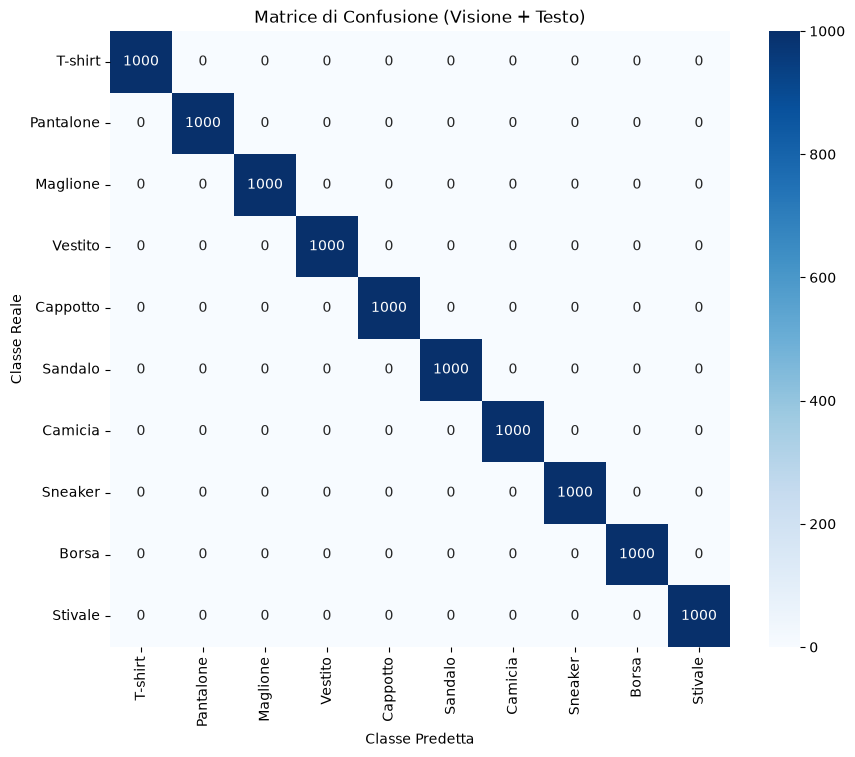

In [1]:
import os  #configurazioe ambiente
import random #generazione casule delle descrizioni simulae
import numpy as np
import matplotlib.pyplot as plt #grafici
import seaborn as sns  #grafici
from sklearn.metrics import confusion_matrix #valutazione classificazione

# Configurazione Backend: Diciamo a Keras di appoggiarsi a PyTorch
# Questa riga deve precedere l'import di keras
os.environ["KERAS_BACKEND"] = "torch"
import keras
import keras.ops as kops

"""
ESEMPIO 73: CLASSIFICAZIONE MULTIMODALE IBRIDA (IMMAGINI + TESTO)
---------------------------------------------------------------
In questo esempio costruiamo un modello che "guarda" un'immagine (Fashion MNIST)
e contemporaneamente "legge" una descrizione testuale (OCR simulato).

L'obiettivo è dimostrare come combinare rami di rete diversi (CNN + NLP) 
in un'unica architettura funzionale.
"""

# ==============================================================================
# 1. PREPARAZIONE DEI DATI: IMMAGINI E TESTO "OCR"
# ==============================================================================

# Carichiamo il dataset Fashion MNIST (immagini 28x28 in bianco e nero)
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.fashion_mnist.load_data()
# fashion_mnist contiene immagini di abbigliamento, ogni immagine è  28x28 pixel scala di grigi
# ogni immagine appartiene a una di queste classi:
# 0 T-shirt/top, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat, 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot

# Prepariamo le immagini: 
# 1. Portiamo i pixel nel range [0, 1] (normalizzazione)
# 2. Aggiungiamo la dimensione del canale (grigio = 1) per la CNN
x_train_img = np.expand_dims(x_train_img.astype("float32") / 255.0, axis=-1) #normalizazione delle immagini ed agginge la dimensnione canale
x_test_img = np.expand_dims(x_test_img.astype("float32") / 255.0, axis=-1)
# inzialente x_train_img.shape =(60.000,28,28) dopo la normalizzazione (60.000,28,28,1) 1 è il canale scala grigi

# --- Simulazione dell'OCR ---
# QUESTO NON è UN VERO OCR, IL CODICE ANDREBBE INTEGRATO CON UN OCR EFFETTIVO
# Creiamo un "vocabolario" di parole tipiche per ogni categoria di abbigliamento.
# Questo simula il testo che un ipotetico sistema OCR leggerebbe da un'etichetta.
vocab_per_classe = {
    0: ["t-shirt", "top", "maglietta", "cotone", "maniche corte", "stampa"],
    1: ["pantaloni", "jeans", "denim", "gambe", "lungo", "tasche"],
    2: ["pullover", "maglione", "lana", "inverno", "caldo", "maniche lunghe"],
    3: ["vestito", "abito", "gonna", "elegante", "sera", "intero"],
    4: ["cappotto", "giacca", "soprabito", "bottoni", "pesante", "esterno"],
    5: ["sandalo", "aperto", "estivo", "mare", "cinturino", "piede"],
    6: ["camicia", "colletto", "elegante", "bottoni", "ufficio", "stirare"],
    7: ["sneaker", "sport", "corsa", "lacci", "comodo", "ginnastica"],
    8: ["borsa", "pelle", "tracolla", "accessorio", "contenitore", "zip"],
    9: ["stivale", "pelle", "inverno", "alto", "tacco", "resistente"]
}

def genera_testo_per_immagini(labels):
    """
    Associa a ogni immagine una stringa di testo basata sulla sua classe reale.
    Prende 3 parole a caso dal relativo vocabolario e talvolta aggiunge 'rumore'.
    """
    testi = []
    for label in labels:
        parole = random.sample(vocab_per_classe[label], k=3)
        # 20% di probabilità di aggiungere una parola inutile ('sconosciuto')
        if random.random() < 0.2: 
            parole.append("sconosciuto") 
        testi.append(" ".join(parole))
    return np.array(testi)

print("Generazione delle descrizioni testuali simulate...")
x_train_text_raw = genera_testo_per_immagini(y_train)
x_test_text_raw = genera_testo_per_immagini(y_test)

# --- Vettorizzazione del Testo ---
# Il modello non legge stringhe, ma numeri. Usiamo TextVectorization per 
# trasformare le parole in indici interi.
MAX_TOKENS = 100 # Numero massimo di parole diverse nel vocabolario
MAX_LEN = 10     # Ogni descrizione sarà troncata o riempita fino a 10 parole

vectorizer = keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

# Analizziamo il testo di training per creare la mappa {parola -> numero}
vectorizer.adapt(x_train_text_raw)

# Applichiamo la trasformazione
x_train_text = vectorizer(x_train_text_raw) #train impara vocabolario
x_test_text = vectorizer(x_test_text_raw) #usa il vocabolario imparato da train

# Convertiamo le etichette in formato "one-hot" (es: 3 diventa [0,0,0,1,0,0,0,0,0,0])
# questo sarà importanto quando fai loss=categorical_crossnentropy
# se avessi lasciato il numero inter e non one-hot avrei dovueto usare sparse_categorical_crossentropy
# entrambe le strade sono valide
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)


# ==============================================================================
# 2. ARCHITETTURA DEL MODELLO (FUNCTIONAL API)
# ==============================================================================

# Abbiamo due ingressi separati che viaggiano in parallelo prima di unirsi.

# --- RAMO VISIONE: Analisi dell'immagine (CNN) --- INPUT 1
# Riceve l'immagine 28x28x1
input_img = keras.Input(shape=(28, 28, 1), name="img_in")    #forma (28,28,1)
x_vis = keras.layers.Conv2D(32, (3,3), activation="relu")(input_img)  #forma (26,26,32)  32 filtri convoluzionali da 3x3
x_vis = keras.layers.MaxPooling2D((2,2))(x_vis)  #RIDUCE forma a 13x13x32
x_vis = keras.layers.Conv2D(64, (3,3), activation="relu")(x_vis) #forma (11,11,64)
# Il GlobalAveragePooling riduce l'immagine a un "vettore di caratteristiche" visive
x_vis = keras.layers.GlobalAveragePooling2D()(x_vis)   #forma (64,) è il riassunto delle caratteristiche rilevete dalla CNN

# --- RAMO TESTO: Analisi del testo (NLP) --- INPUT 2
# Riceve i 10 numeri interi che rappresentano le parole
input_txt = keras.Input(shape=(MAX_LEN,), name="txt_in")   #shape=10
# L'Embedding trasforma ogni indice in un vettore denso di significato (dimensione 32)
x_txt = keras.layers.Embedding(input_dim=MAX_TOKENS, output_dim=32)(input_txt) #shape(10x32) trasforma ogni ID del precedente layer in un vettore in questo caso lungo 32
# Riassumiamo il significato della frase in un unico vettore
x_txt = keras.layers.GlobalAveragePooling1D()(x_txt)  #(1,32) dei 10 vettori da 32 fa la media ed ottiene 1 vettore da 32

# --- FUSIONE (Concatenazione) ---   CONCATENAZIOE INPUT 1 E INPUT 2
# Qui avviene la magia: attacchiamo il vettore visivo al vettore testuale.
# Il modello ora ha una visione "completa" dell'oggetto.
combined = keras.layers.Concatenate()([x_vis, x_txt])
# concatena il ramo visivo shape 64 e il ramo testo shape 32 = 96 valori

# --- TESTA DI CLASSIFICAZIONE ---
# Elaboriamo le informazioni unite per arrivare alla decisione finale
z = keras.layers.Dense(64, activation="relu")(combined) #la Dense prende le 96 informazioni fuse e impare combinazioni portando a 64 la shape
z = keras.layers.Dropout(0.3)(z) # Evitiamo l'overfitting spegnendo neuroni a caso 
output = keras.layers.Dense(10, activation="softmax", name="prediction")(z) #softmax produce una distribuzione per ogni classe (le classi sono 10)

# Creiamo l'oggetto modello definendo chiaramente i 2 ingressi e le 10 uscite (classi)
model = keras.Model(inputs=[input_img, input_txt], outputs=output)

model.compile(
    optimizer="adam", #adam aggiorna i pesi
    loss="categorical_crossentropy",
    metrics=["accuracy"] #accuracy misura quante classi vengono previste correttamente
)


# ==============================================================================
# 3. ADDESTRAMENTO (TRAINING)
# ==============================================================================

print("\nAvvio dell'addestramento ibrido...")
# Passiamo un dizionario per mappare i dati agli ingressi corretti definiti sopra
model.fit(
    x={"img_in": x_train_img, "txt_in": x_train_text},
    y=y_train_cat,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


# ==============================================================================
# 4. TEST E INFERENZA SINGOLA (EVALUATE)
# ==============================================================================

print("\n--- Valutazione Finale ---")
results = model.evaluate({"img_in": x_test_img, "txt_in": x_test_text}, y_test_cat)
print(f"Accuratezza Modello Ibrido: {results[1]*100:.2f}%")

# Proviamo a fare una previsione su un singolo esempio (il primo del test set)
idx = 0

# Nota tecnica: Se lavoriamo su GPU con PyTorch, dobbiamo assicurarci che i dati 
# siano in formato Numpy per alcune manipolazioni locali.
sample_img_np = kops.convert_to_numpy(x_test_img[idx])
sample_txt_np = kops.convert_to_numpy(x_test_text[idx])

# Aggiungiamo la dimensione batch (da 1 diventano (1, ...)) richiesta dal modello
sample_img = np.expand_dims(sample_img_np, axis=0)
sample_txt = np.expand_dims(sample_txt_np, axis=0)

# Eseguiamo la previsione
pred = model.predict({"img_in": sample_img, "txt_in": sample_txt}, verbose=0)
predicted_label = np.argmax(pred)
true_label = y_test[idx]

print(f"\nDescrizione letta dall'OCR: {x_test_text_raw[idx]}")
print(f"ID Classe Reale: {true_label} | ID Predetto: {predicted_label}")
print("Risultato:", "CORRETTO" if predicted_label == true_label else "ERRORE")


# ==============================================================================
# 5. ANALISI DEI RISULTATI: MATRICE DI CONFUSIONE
# ==============================================================================
print("\nGenerazione Matrice di Confusione...")

# Otteniamo le predizioni per tutti i 10.000 esempi di test
all_preds_probs = model.predict({"img_in": x_test_img, "txt_in": x_test_text}, verbose=1)
y_pred_classes = np.argmax(all_preds_probs, axis=1)

# Calcoliamo la matrice che mostra dove il modello si confonde
cm = confusion_matrix(y_test, y_pred_classes)

# Disegniamo la matrice per renderla leggibile
nomi_classi = ["T-shirt", "Pantalone", "Maglione", "Vestito", "Cappotto", 
               "Sandalo", "Camicia", "Sneaker", "Borsa", "Stivale"]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomi_classi, 
            yticklabels=nomi_classi)

plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.title('Matrice di Confusione (Visione + Testo)')
plt.show()